In [5]:
import opt_einsum as oe
import numpy as np
import torch
import sys
sys.path.append("../../")
import mps
from mps.trainer.data_utils import SyntheticDataset, SyntheticDatasetV2, SyntheticDatasetV3

import mps

In [168]:
N = 40
batch_size = 100

x0 = torch.randint(0, 2, (batch_size, N)).to(torch.float64)
x0[:, 0] = 1

x1 = x0.clone()
x1[:, 0] = 0

psi0 = torch.stack([x0, 1 - x0], dim=-1)
psi1 = torch.stack([x1, 1 - x1], dim=-1)

psi = torch.concat([psi0, psi1], dim=0)


In [169]:
from mps.tpcp_mps import MPSTPCP


tpcp = MPSTPCP(N, K=1, d=2, enable_r=True, with_identity=False, manifold=mps.tpcp_mps.ManifoldType.CANONICAL)

In [170]:
import geoopt
optimizer = geoopt.optim.RiemannianSGD(tpcp.params, lr=0.01)
tpcp.forward(psi)
loss = (tpcp.rho_list[-1][:batch_size] - tpcp.rho_list[-1][batch_size:]).norm()
loss.backward()
print(loss)

tensor(3.3069e-06, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>)


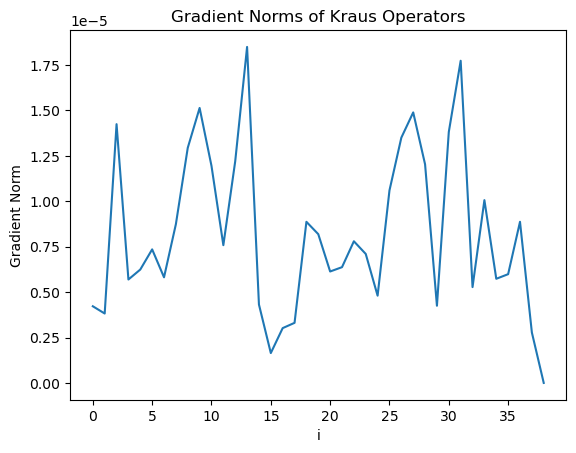

In [171]:
import matplotlib.pyplot as plt

norms = []
for i in range(len(tpcp.kraus_ops)):
    g = tpcp.kraus_ops[i].grad
    u = tpcp.kraus_ops[i]
    rg = u.T @ g - g.T @ u
    norms.append(torch.norm(rg).item())

plt.plot(norms)
plt.xlabel('i')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norms of Kraus Operators')
plt.show()

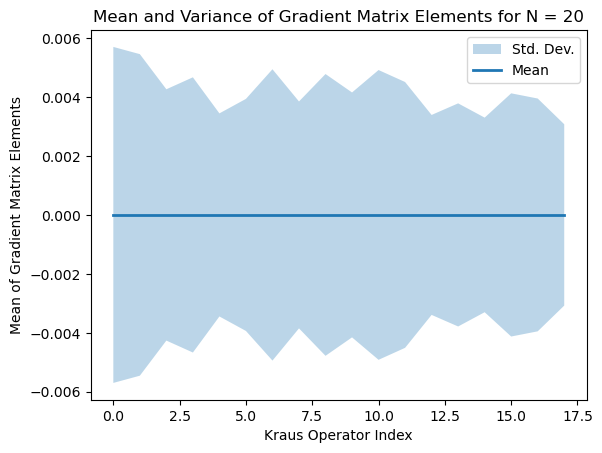

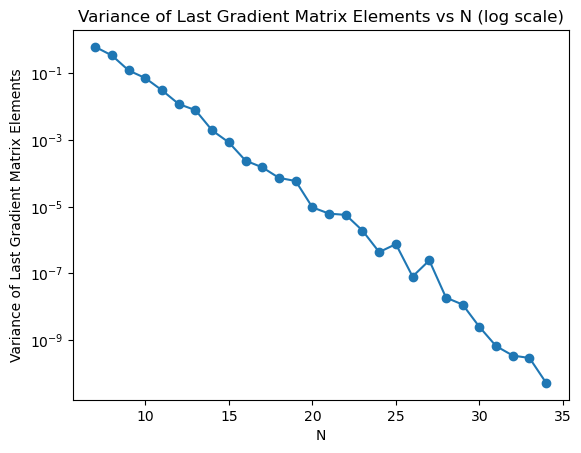

In [ ]:
import mps.tpcp_mps
import opt_einsum as oe
import numpy as np
import torch
import sys
sys.path.append("../../")
import mps
from mps.trainer.data_utils import SyntheticDataset, SyntheticDatasetV2, SyntheticDatasetV3
import geoopt
import matplotlib.pyplot as plt
import math

# Set number of independent experiments per N
M = 300
# Use N values from 11 to 21 (inclusive)
N_list = list(range(7, 35))
batch_size = 100

# Dictionaries to store mean and variance (of the gradient matrix elements) for each N.
mean_dict = {}
var_dict = {}
# Also store the variance (aggregated over experiments) of the last Kraus operator's gradient matrix elements.
last_grad_variances = []

# Loop over different system sizes N
for N in N_list:
    # For each Kraus operator (except the last one), we will collect all the matrix elements
    # (from R = u.T @ g - g.T @ u) over M experiments.
    operator_elements = None

    for m in range(M):
        # --- Initialize the tpcp model ---
        tpcp = mps.tpcp_mps.MPSTPCP(
            N, K=1, d=2, enable_r=True, with_identity=False, 
            manifold=mps.tpcp_mps.ManifoldType.CANONICAL
        )
        
        # Create an optimizer (Riemannian SGD) over the model parameters.
        optimizer = geoopt.optim.RiemannianSGD(tpcp.params, lr=0.01)
        
        # --- Generate synthetic data ---
        x0 = torch.randint(0, 2, (batch_size, N), dtype=torch.int64).to(torch.float64)
        x0[:, 0] = 1  # force the first bit to 1
        x1 = x0.clone()
        x1[:, 0] = 0  # force the first bit to 0
        
        psi0 = torch.stack([x0, 1 - x0], dim=-1)
        psi1 = torch.stack([x1, 1 - x1], dim=-1)
        psi = torch.cat([psi0, psi1], dim=0)
        
        # --- Forward pass, loss, and backward pass ---
        tpcp.forward(psi)
        loss = (tpcp.rho_list[-1][:batch_size] - tpcp.rho_list[-1][batch_size:]).norm()
        optimizer.zero_grad()
        loss.backward()
        
        # On the first experiment, initialize operator_elements as a list of empty lists,
        # one for each Kraus operator (excluding the last one, as in your current implementation)
        if operator_elements is None:
            num_ops = len(tpcp.kraus_ops) - 1
            operator_elements = [[] for _ in range(num_ops)]
        
        # --- Compute the gradient matrix for each Kraus operator and accumulate all its elements ---
        for i, op in enumerate(tpcp.kraus_ops[:-1]):
            g = op.grad
            u = op
            # Compute the anti-Hermitian part:
            rg = u.T @ g - g.T @ u
            # Flatten the matrix and convert to numpy
            rg_flat = rg.flatten().detach().cpu().numpy()
            operator_elements[i].extend(rg_flat.tolist())
    
    # After M experiments, compute the overall mean and variance (across all individual matrix elements)
    # for each Kraus operator index.
    mean_vals = []
    var_vals = []
    for elements in operator_elements:
        mean_vals.append(np.mean(elements))
        var_vals.append(np.var(elements))
    
    mean_dict[N] = mean_vals
    var_dict[N] = var_vals
    # Save the variance for the last Kraus operator's gradient matrix elements.
    last_grad_variances.append(var_vals[-1])


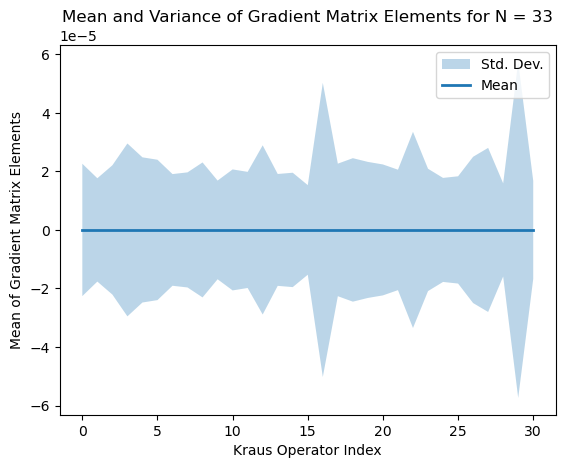

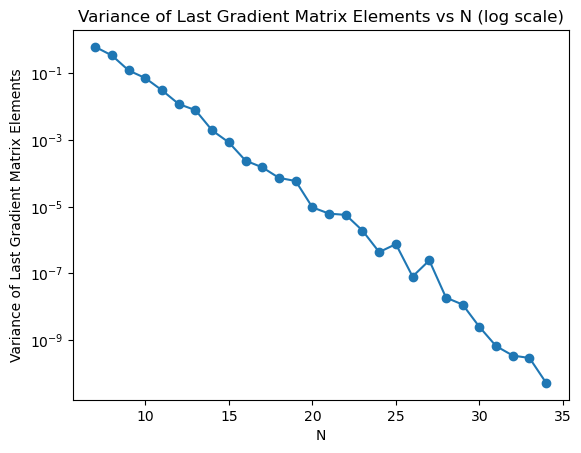

In [186]:
# --- Plot 1: Mean and standard deviation (filled area) for a given N ---
# For illustration, we choose N = 20.
N_plot = 33
mean_vals = mean_dict[N_plot]
std_vals = np.sqrt(var_dict[N_plot])
i_indices = np.arange(len(mean_vals))

plt.figure()
plt.fill_between(i_indices, np.array(mean_vals) - np.array(std_vals), np.array(mean_vals) + np.array(std_vals), 
                 alpha=0.3, label='Std. Dev.')
plt.plot(i_indices, mean_vals, linewidth=2, label='Mean')
plt.xlabel('Kraus Operator Index')
plt.ylabel('Mean of Gradient Matrix Elements')
plt.title(f'Mean and Variance of Gradient Matrix Elements for N = {N_plot}')
plt.legend()
plt.show()

# --- Plot 2: Log plot of the variance of the last Kraus operator's gradient matrix elements vs N ---
plt.figure()
plt.plot(N_list, last_grad_variances, marker='o')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('Variance of Last Gradient Matrix Elements')
plt.title('Variance of Last Gradient Matrix Elements vs N (log scale)')
plt.show()
